# STAR: Two-Stage Attention-Based Hierarchical Transformer for RUL Prediction

Dataset: NASA C-MAPSS FD001

## 1. Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# Set random seeds
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.7.0+cpu


In [7]:
INPUT_PATH = 'datasets'

## 2. Data Loading, EDA & Preprocessing

In [8]:
# Load C-MAPSS data
def load_cmapss_data(filepath):
    """Load C-MAPSS dataset"""
    columns = ['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]
    df = pd.read_csv(filepath, sep='\s+', header=None, names=columns)
    return df

# Load training and test data
train_df = load_cmapss_data(f'{INPUT_PATH}/train_FD001.txt')
test_df = load_cmapss_data(f'{INPUT_PATH}/test_FD001.txt')
rul_df = pd.read_csv(f'{INPUT_PATH}/RUL_FD001.txt', header=None, names=['rul'])

print(f"Train data: {len(train_df)} records, {train_df['unit'].nunique()} units")
print(f"Test data: {len(test_df)} records, {test_df['unit'].nunique()} units")

Train data: 20631 records, 100 units
Test data: 13096 records, 100 units
Selected sensors: 14


In [12]:
train_df.head()

,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 2.1. Exploratory Data Analysis (EDA)

In [11]:
# Overview
print(f"\nTraining set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"\nNumber of engines (train): {train_df['unit'].nunique()}")
print(f"Number of engines (test): {test_df['unit'].nunique()}")
print(f"\nCycles per engine (train):")
print(train_df.groupby('unit')['cycle'].max().describe())


Training set shape: (20631, 26)
Test set shape: (13096, 26)

Number of engines (train): 100
Number of engines (test): 100

Cycles per engine (train):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [20]:
train_df.groupby("unit")["cycle"].max()

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [13]:
# SENSOR VARIANCE ANALYSI
sensor_cols = [f's{i}' for i in range(1, 22)]
sensor_stats = pd.DataFrame({
    'sensor': sensor_cols,
    'mean': train_df[sensor_cols].mean(),
    'std': train_df[sensor_cols].std(),
    'min': train_df[sensor_cols].min(),
    'max': train_df[sensor_cols].max(),
    'range': train_df[sensor_cols].max() - train_df[sensor_cols].min()
})

sensor_stats['cv'] = sensor_stats['std'] / sensor_stats['mean']  # Coefficient of variation
sensor_stats = sensor_stats.sort_values('std', ascending=False)

print("\nSensor statistics (sorted by std):")
print(sensor_stats.to_string(index=False))

# Identify constant/low-variance sensors
low_var_threshold = 0.01
low_var_sensors = sensor_stats[sensor_stats['std'] < low_var_threshold]['sensor'].tolist()
print(f"\nLow variance sensors (std < {low_var_threshold}): {low_var_sensors}")
print(f"These sensors have minimal variation and may not be useful for prediction.")


Sensor statistics (sorted by std):
sensor        mean          std       min       max    range           cv
    s9 9065.242941 2.208288e+01 9021.7300 9244.5900 222.8600 2.435994e-03
   s14 8143.752722 1.907618e+01 8099.9400 8293.7200 193.7800 2.342431e-03
    s4 1408.933782 9.000605e+00 1382.2500 1441.4900  59.2400 6.388238e-03
    s3 1590.523119 6.131150e+00 1571.0400 1616.9100  45.8700 3.854801e-03
   s17  393.210654 1.548763e+00  388.0000  400.0000  12.0000 3.938762e-03
    s7  553.367711 8.850923e-01  549.8500  556.0600   6.2100 1.599465e-03
   s12  521.413470 7.375534e-01  518.6900  523.3800   4.6900 1.414527e-03
    s2  642.680934 5.000533e-01  641.2100  644.5300   3.3200 7.780739e-04
   s11   47.541168 2.670874e-01   46.8500   48.5300   1.6800 5.618023e-03
   s20   38.816271 1.807464e-01   38.1400   39.4300   1.2900 4.656460e-03
   s21   23.289705 1.082509e-01   22.8942   23.6184   0.7242 4.648014e-03
   s13 2388.096152 7.191892e-02 2387.8800 2388.5600   0.6800 3.011559e-05
  

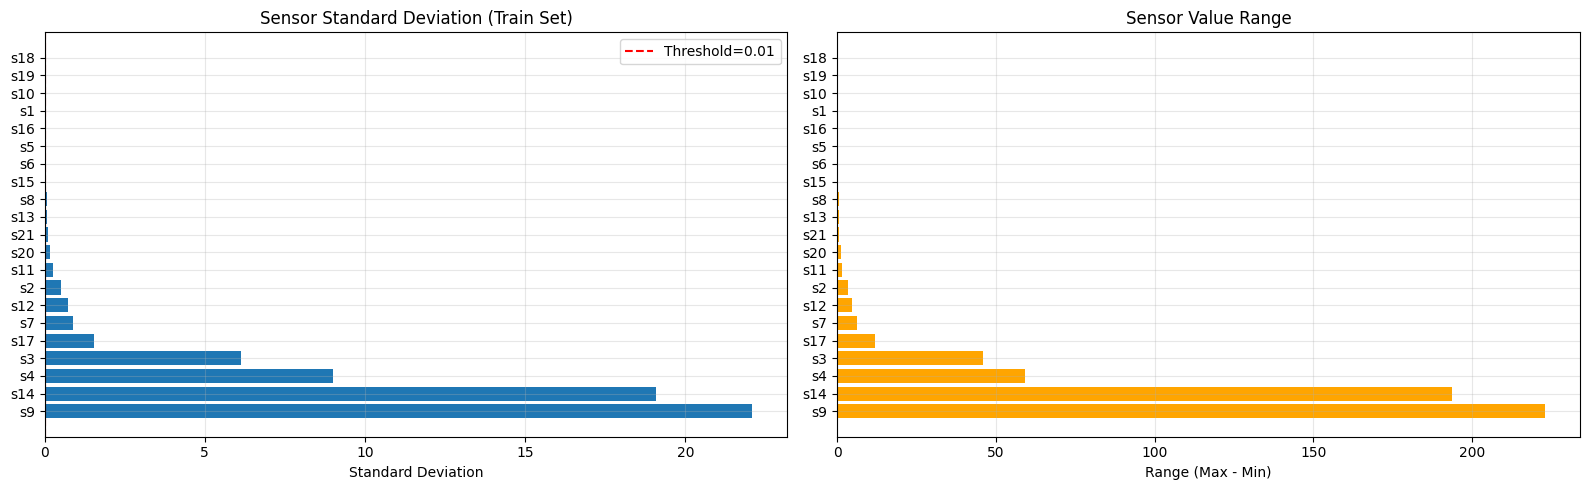

In [14]:
# Plot sensor variance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot of std
axes[0].barh(range(len(sensor_stats)), sensor_stats['std'].values)
axes[0].set_yticks(range(len(sensor_stats)))
axes[0].set_yticklabels(sensor_stats['sensor'].values)
axes[0].set_xlabel('Standard Deviation')
axes[0].set_title('Sensor Standard Deviation (Train Set)')
axes[0].axvline(x=low_var_threshold, color='r', linestyle='--', label=f'Threshold={low_var_threshold}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of range
axes[1].barh(range(len(sensor_stats)), sensor_stats['range'].values, color='orange')
axes[1].set_yticks(range(len(sensor_stats)))
axes[1].set_yticklabels(sensor_stats['sensor'].values)
axes[1].set_xlabel('Range (Max - Min)')
axes[1].set_title('Sensor Value Range')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** Sensors with high variance/range are more likely to be informative for RUL prediction.


setting_1:
  Unique values: 158
  Range: [-0.0087, 0.0087]
  Std: 0.0022

setting_2:
  Unique values: 13
  Range: [-0.0006, 0.0006]
  Std: 0.0003

setting_3:
  Unique values: 1
  Range: [100.0000, 100.0000]
  Std: 0.0000
  Values: [np.float64(100.0)]


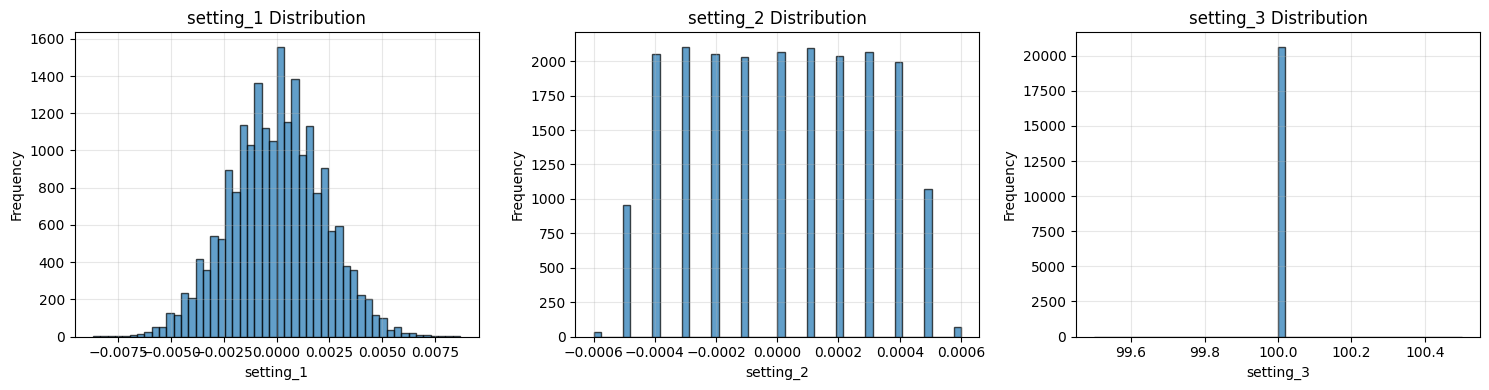

In [15]:
# OPERATIONAL SETTINGS ANALYSIS
settings = ['setting_1', 'setting_2', 'setting_3']
for setting in settings:
    unique_vals = train_df[setting].nunique()
    print(f"\n{setting}:")
    print(f"  Unique values: {unique_vals}")
    print(f"  Range: [{train_df[setting].min():.4f}, {train_df[setting].max():.4f}]")
    print(f"  Std: {train_df[setting].std():.4f}")
    if unique_vals <= 10:
        print(f"  Values: {sorted(train_df[setting].unique())}")

# FD001 is single operating condition - settings should be constant
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, setting in enumerate(settings):
    axes[i].hist(train_df[setting], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(setting)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{setting} Distribution')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Note:** FD001 represents a single operating condition, so settings show minimal variation.

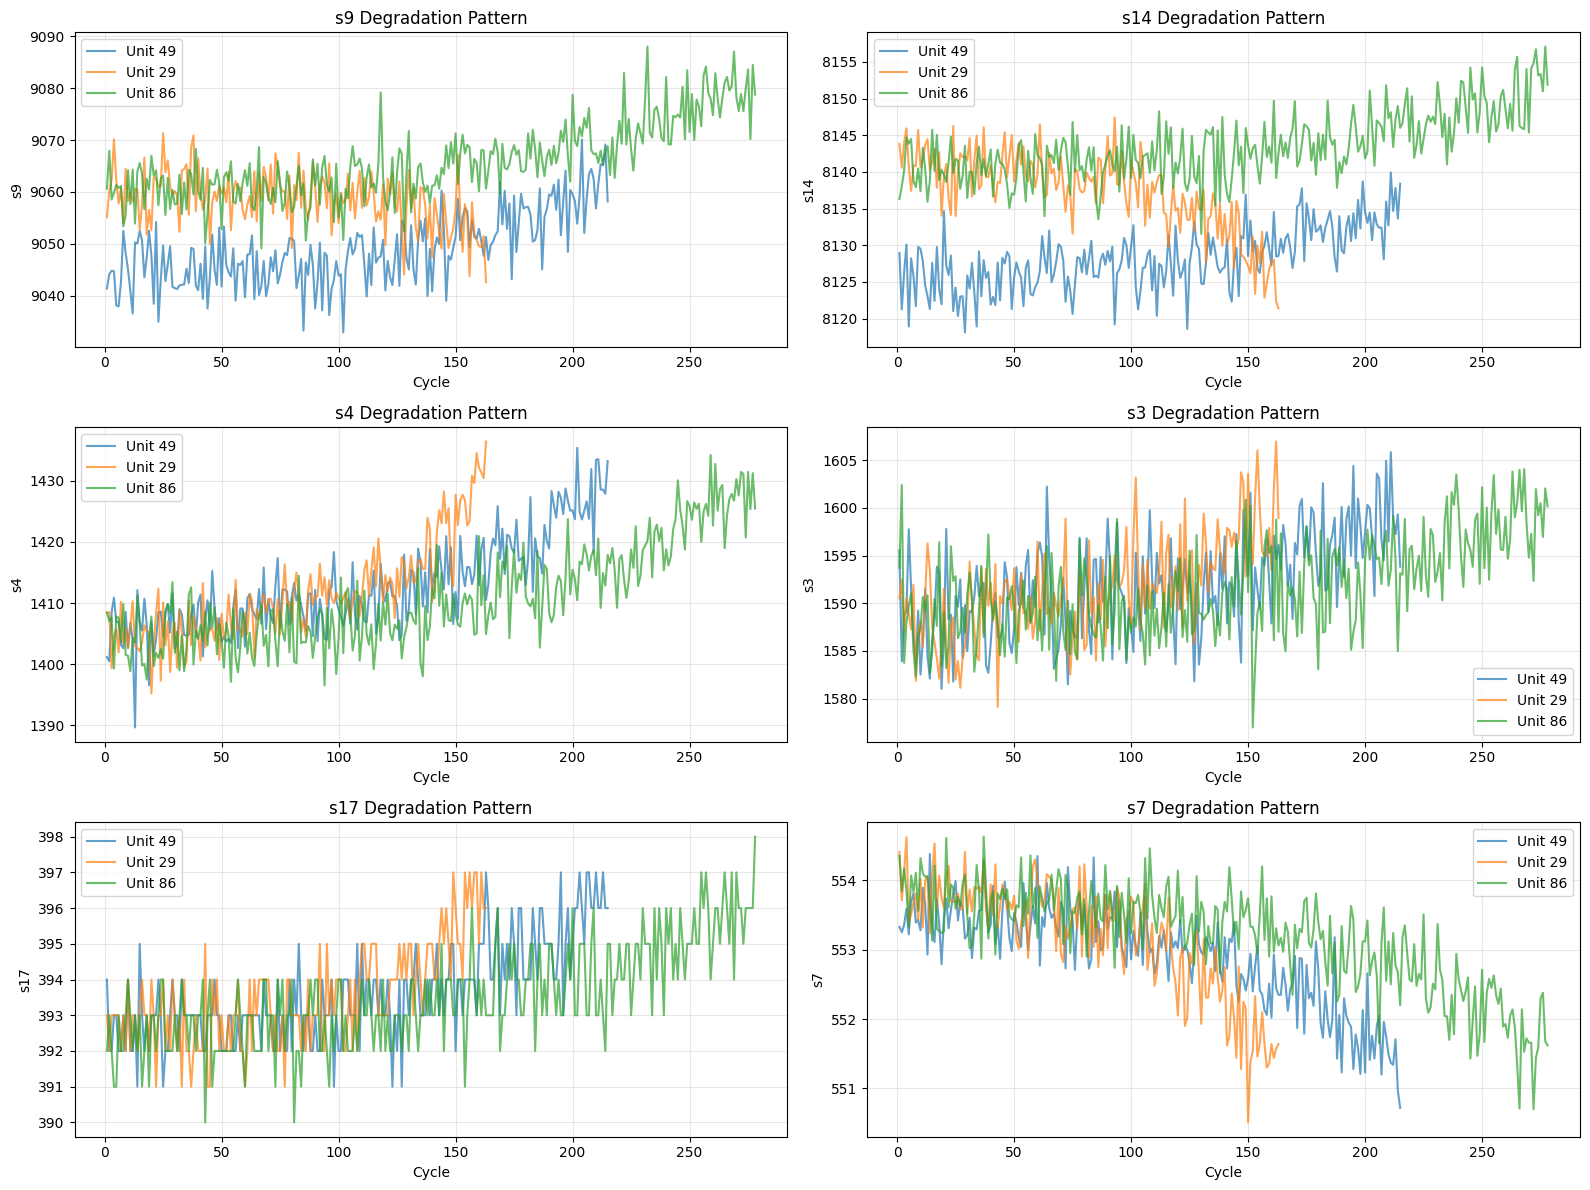

In [18]:
# SENSOR DEGRADATION PATTERNS

# Pick 3 random engines
sample_units = np.random.choice(train_df['unit'].unique(), 3, replace=False)

# Select some informative sensors (high variance ones)
informative_sensors = sensor_stats.head(6)['sensor'].tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, sensor in enumerate(informative_sensors):
    for unit in sample_units:
        unit_data = train_df[train_df['unit'] == unit]
        axes[idx].plot(unit_data['cycle'], unit_data[sensor], alpha=0.7, label=f'Unit {unit}')
    
    axes[idx].set_xlabel('Cycle')
    axes[idx].set_ylabel(sensor)
    axes[idx].set_title(f'{sensor} Degradation Pattern')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** Different sensors show different degradation patterns over engine lifetime.

SENSOR CORRELATION ANALYSIS


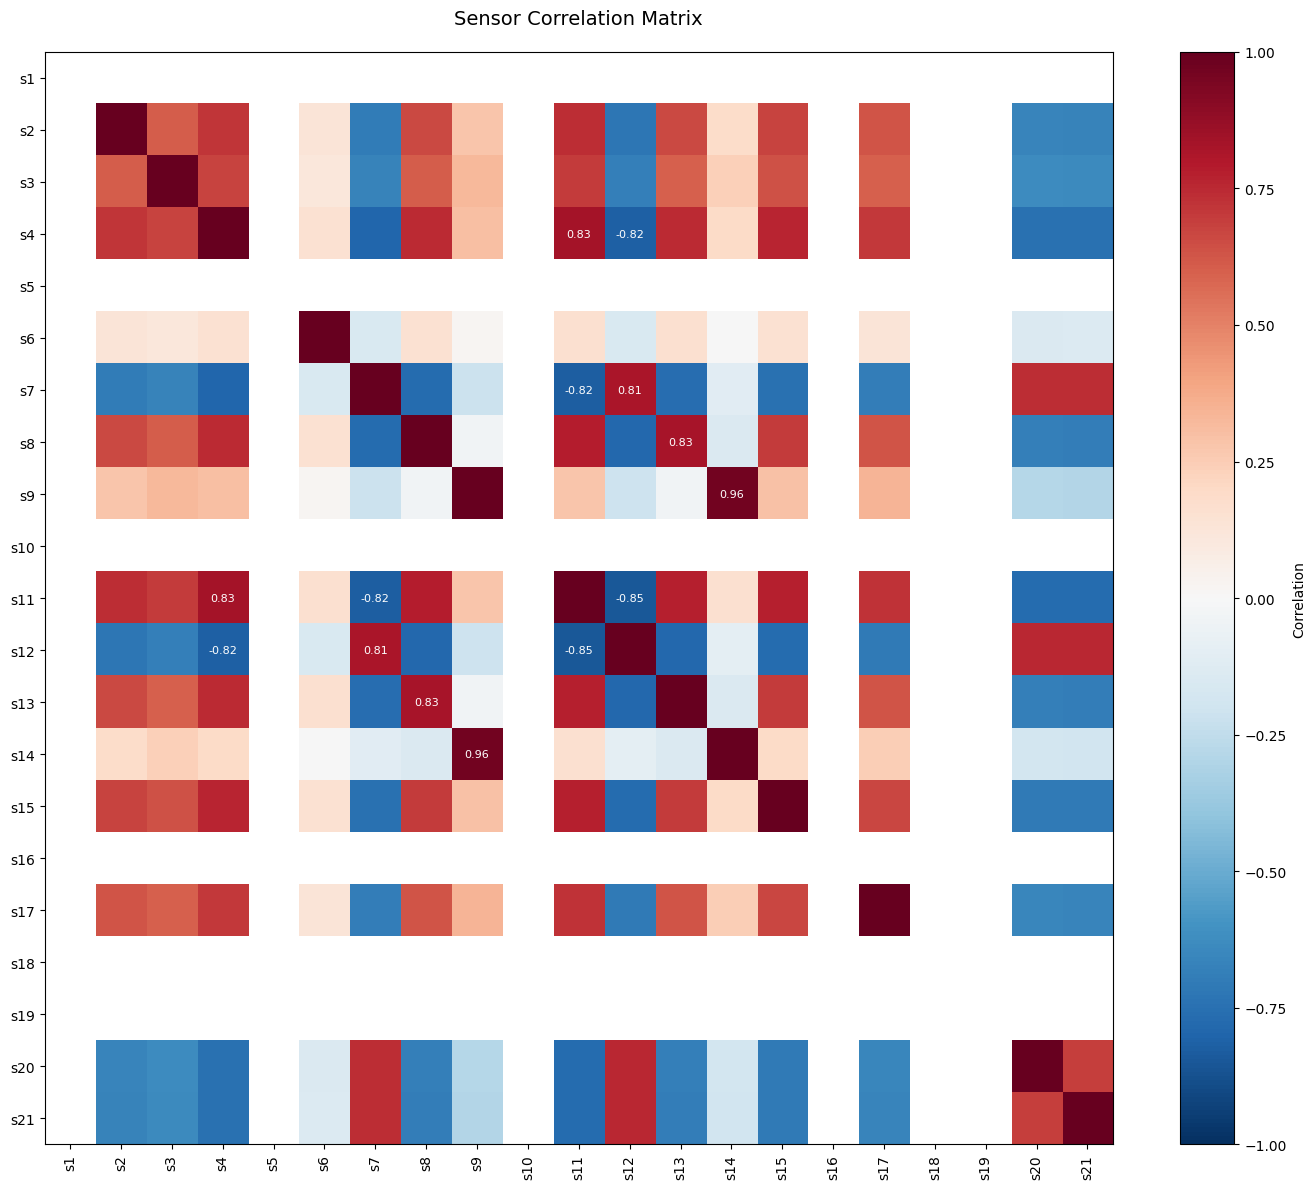


Highly correlated sensor pairs (|r| > 0.9):
  s9 ↔ s14: 0.963


In [22]:
# Correlation analysis
print("SENSOR CORRELATION ANALYSIS")

# Compute correlation matrix
all_sensors = [f's{i}' for i in range(1, 22)]
corr_matrix = train_df[all_sensors].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
im = plt.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, label='Correlation')
plt.xticks(range(len(all_sensors)), all_sensors, rotation=90)
plt.yticks(range(len(all_sensors)), all_sensors)
plt.title('Sensor Correlation Matrix', fontsize=14, pad=20)

# Add correlation values
for i in range(len(all_sensors)):
    for j in range(len(all_sensors)):
        if abs(corr_matrix.iloc[i, j]) > 0.8 and i != j:
            plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                    ha='center', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(all_sensors)):
    for j in range(i+1, len(all_sensors)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((all_sensors[i], all_sensors[j], corr_matrix.iloc[i, j]))

print(f"\nHighly correlated sensor pairs (|r| > 0.9):")
for s1, s2, corr in high_corr_pairs:
    print(f"  {s1} ↔ {s2}: {corr:.3f}")

**Note:** Highly correlated sensors may provide redundant information.

Potential interrelationships within the system, grounded in the principles of physics and operational mechanics:

**Features Related to Temperature:**

- Fan Inlet Temperature (°R): This is the air temperature as it enters the fan.
- LPC Outlet Temperature (°R): This is the temperature after the air has passed through the Low-Pressure Compressor (LPC).
- HPC Outlet Temperature (°R): This is the temperature after the air has passed through the High-Pressure Compressor (HPC).
- LPT Outlet Temperature (°R): This is the temperature after the air has passed through the Low-Pressure Turbine (LPT).

Given the thermodynamic cycle of a jet engine, we can expect certain correlations among these temperature readings. For example, an increase in the fan inlet temperature could lead to corresponding increases in the temperatures post the compressors and turbines. However, factors such as the efficiency of the compressors and turbines could also influence these correlations. Notably, the HPC outlet temperature and LPT outlet temperature are often strongly correlated, particularly if the efficiency of the HPC directly impacts the LPT.

**Features Related to Pressure:**

- Fan Inlet Pressure (psia): This is the air pressure at the point of entry into the fan.
- Bypass-Duct Pressure (psia): This is the pressure within the bypass duct of a turbofan.
- HPC Outlet Pressure (psia): This is the pressure after the air has passed through the High-Pressure Compressor.
- HPC Outlet Static Pressure (psia): This is the static pressure after the air has passed through the High-Pressure Compressor.

Typically, the HPC outlet pressure and HPC outlet static pressure are measurements of pressure at the same location but from different perspectives (total vs static). The HPC outlet pressure generally refers to the total pressure (comprising both static and dynamic components), while the HPC outlet static pressure pertains only to the static component. The dynamic component is linked to the flow velocity. In situations where the velocity (and hence the dynamic pressure) doesn't vary significantly, the difference between these two pressures might be minimal. Therefore, one of these features could potentially be dropped after assessing their significance to the model.

**Features Related to Speed:**

- Physical Fan Speed (rpm)
- Physical Core Speed (rpm)
- Corrected Fan Speed (rpm)
- Corrected Core Speed (rpm)

The physical and corrected speeds for the same component (either the fan or the core) are likely to be correlated. The corrected speed is essentially the physical speed adjusted for ambient conditions. Depending on the specific use case, you might opt to use either the physical or corrected speed, but may not require both.

Other Features: Features like the Engine Pressure Ratio (P50/P2), which represents a ratio of pressures, might also be correlated with individual pressure readings. This would need to be confirmed with data.

Cool Air Flow Features:

- High-Pressure Turbines Cool Air Flow
- Low-Pressure Turbines Cool Air Flow

Depending on the engine's design and operation, these could be correlated, especially if the cooling air flows are interconnected or influenced by similar operational conditions.


SENSOR DISTRIBUTION ANALYSIS


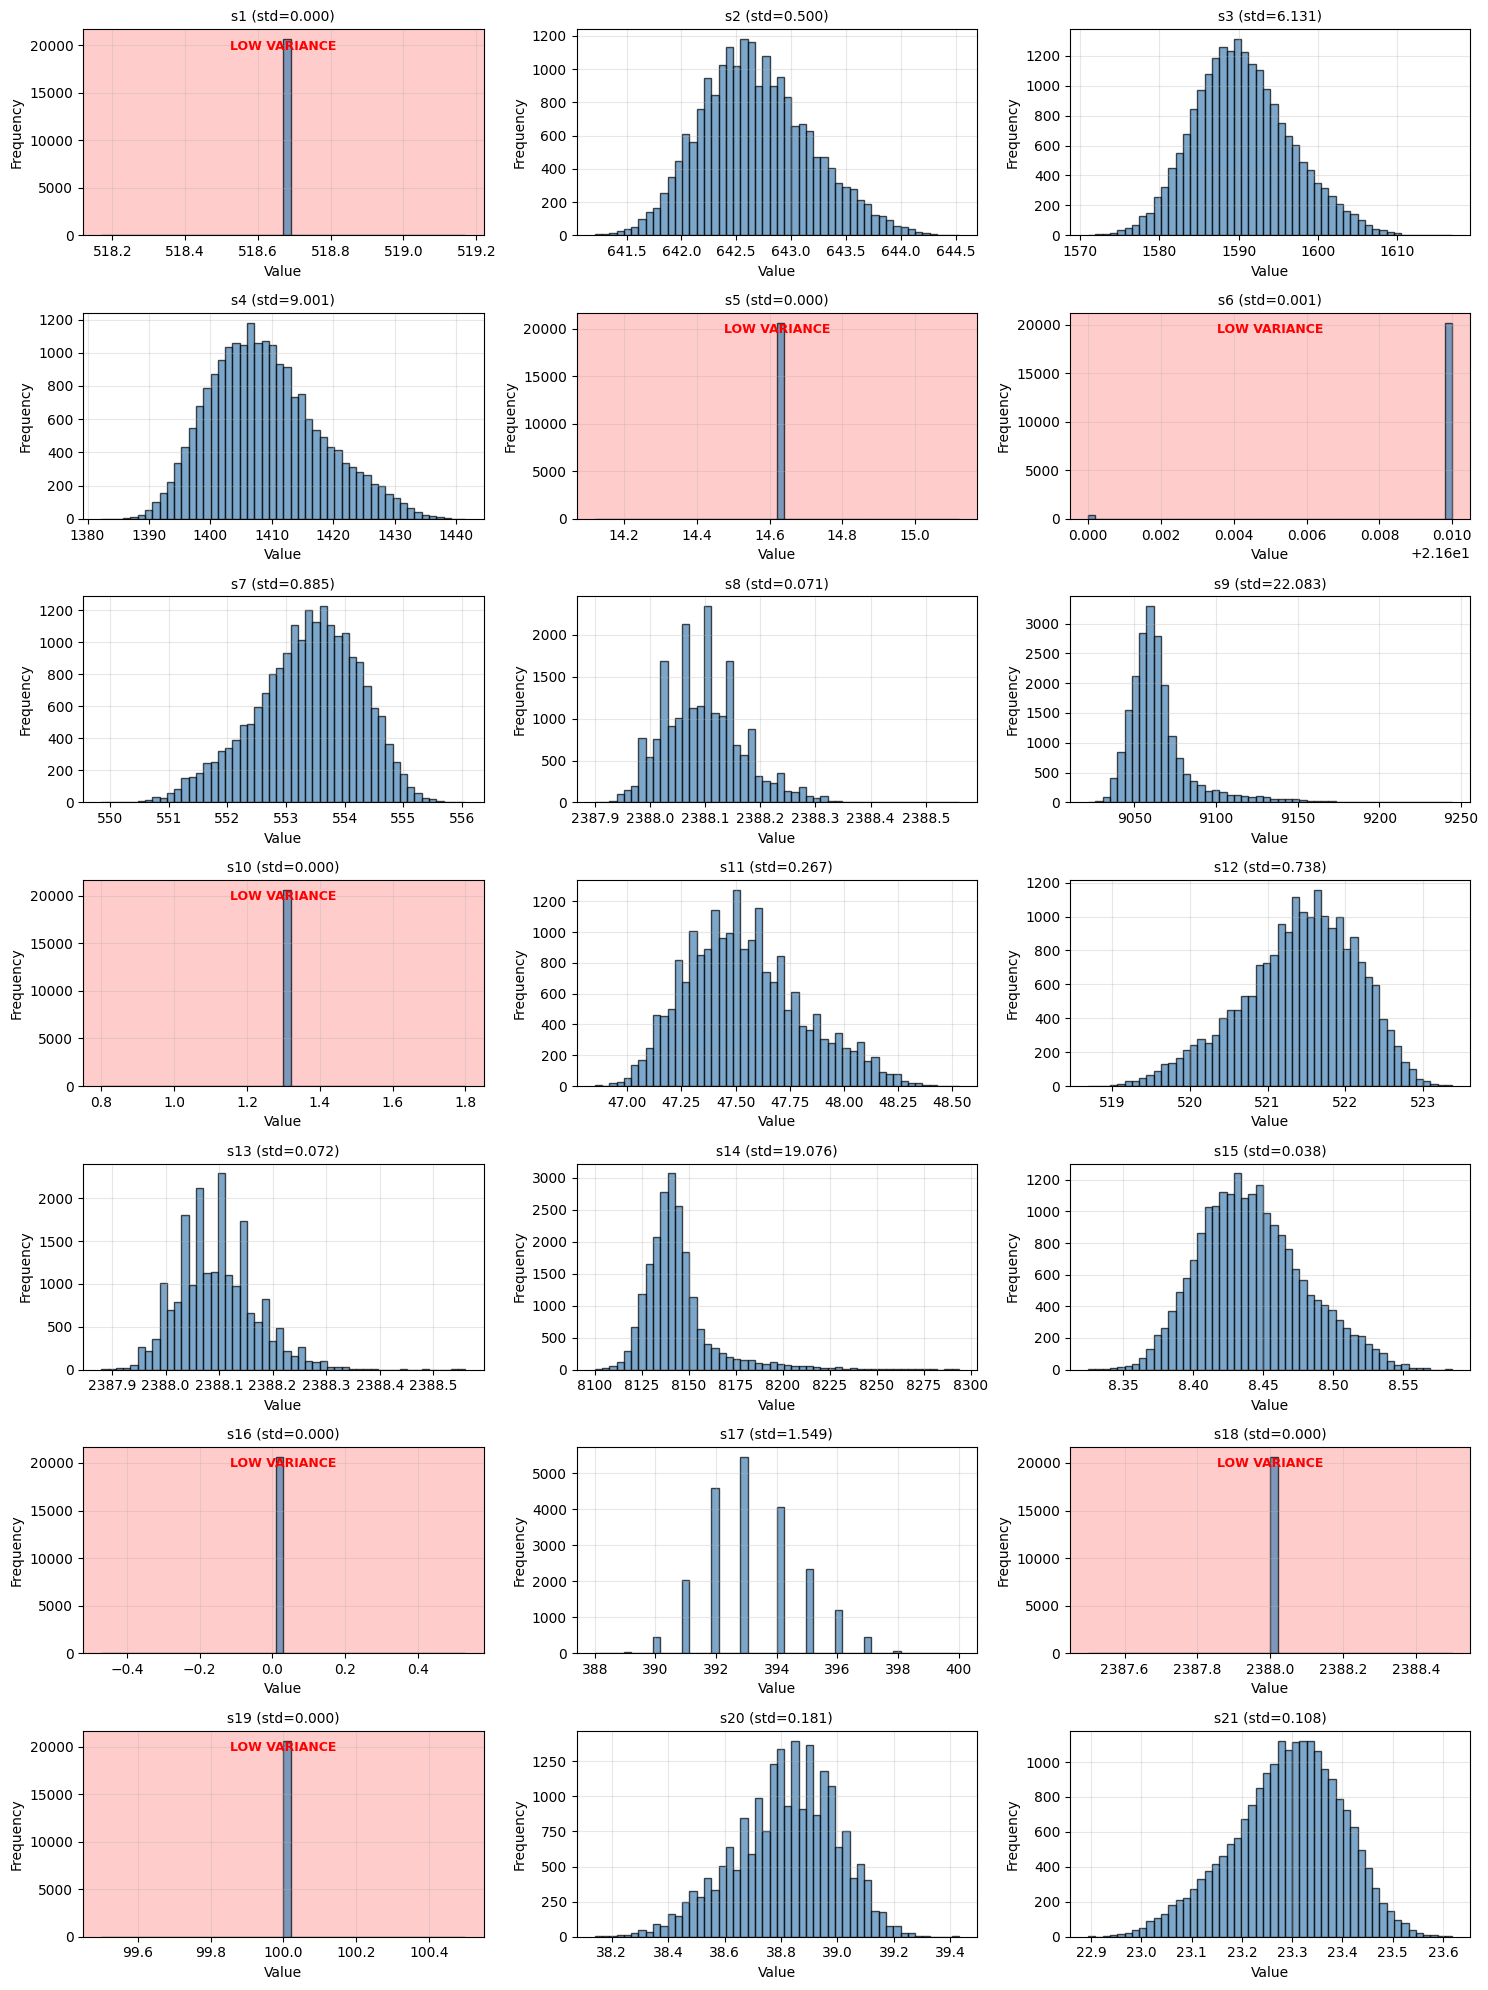

In [23]:
# Distribution analysis for all sensors
print("\n" + "=" * 80)
print("SENSOR DISTRIBUTION ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

for idx, sensor in enumerate(all_sensors):
    axes[idx].hist(train_df[sensor], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{sensor} (std={train_df[sensor].std():.3f})', fontsize=10)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Highlight if low variance
    if train_df[sensor].std() < low_var_threshold:
        axes[idx].set_facecolor('#ffcccc')
        axes[idx].text(0.5, 0.95, 'LOW VARIANCE', transform=axes[idx].transAxes,
                      ha='center', va='top', fontsize=9, color='red', weight='bold')

plt.tight_layout()
plt.show()

**Note:** Sensors with red background have low variance and are less useful.

### 2.2. Sensor Selection Rationale

In [30]:
# Summary of EDA findings
print("=" * 80)
print("EDA CONCLUSIONS & SENSOR SELECTION")
print("=" * 80)

print("\nKey Findings from EDA:")
print("\n1. LOW VARIANCE SENSORS:")
print(f"   Sensors with std < {low_var_threshold}: {low_var_sensors}")
print("   → These sensors show minimal variation and provide little information")
print("   → Should be excluded from modeling")

print("\n2. HIGHLY CORRELATED SENSORS:")
high_corr_count = len([p for p in high_corr_pairs if abs(p[2]) > 0.95])
print(f"   Found {high_corr_count} sensor pairs with |correlation| > 0.95")
print("   → Redundant information, may lead to multicollinearity")

print("\n3. INFORMATIVE SENSORS:")
high_var_sensors = sensor_stats[sensor_stats['std'] > 0.1]['sensor'].tolist()
print(f"   Sensors with std > 0.1: {high_var_sensors}")
print(f"   → Total: {len(high_var_sensors)} sensors show significant variation")

print("\n4. OPERATIONAL SETTINGS:")
print("   All 3 settings show minimal variation (FD001 = single operating condition)")
print("   → Settings can be used as static features but have limited predictive power")


EDA CONCLUSIONS & SENSOR SELECTION

Key Findings from EDA:

1. LOW VARIANCE SENSORS:
   Sensors with std < 0.01: ['s6', 's5', 's16', 's1', 's10', 's19', 's18']
   → These sensors show minimal variation and provide little information
   → Should be excluded from modeling

2. HIGHLY CORRELATED SENSORS:
   Found 1 sensor pairs with |correlation| > 0.95
   → Redundant information, may lead to multicollinearity

3. INFORMATIVE SENSORS:
   Sensors with std > 0.1: ['s9', 's14', 's4', 's3', 's17', 's7', 's12', 's2', 's11', 's20', 's21']
   → Total: 11 sensors show significant variation

4. OPERATIONAL SETTINGS:
   All 3 settings show minimal variation (FD001 = single operating condition)
   → Settings can be used as static features but have limited predictive power


In [ ]:
# Select sensors (14 sensors)
SENSORS = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
SENSOR_COLS = [f's{i}' for i in SENSORS]

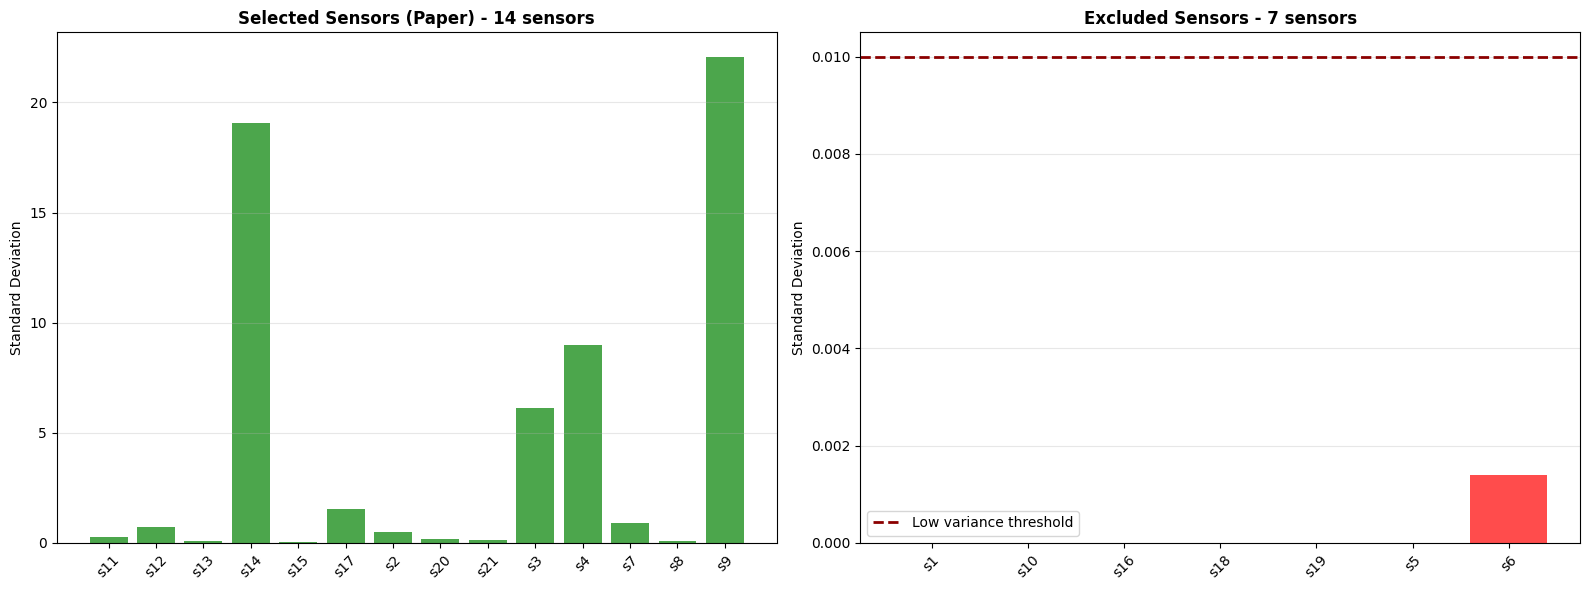

In [ ]:
# Visualize selected vs excluded sensors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

selected_indices = [int(s[1:]) for s in SENSOR_COLS]
selected_stats = sensor_stats[sensor_stats['sensor'].isin(SENSOR_COLS)].sort_values('sensor')

ax1.bar(range(len(selected_stats)), selected_stats['std'].values, color='green', alpha=0.7)
ax1.set_xticks(range(len(selected_stats)))
ax1.set_xticklabels(selected_stats['sensor'].values, rotation=45)
ax1.set_ylabel('Standard Deviation')
ax1.set_title(f'Selected Sensors - {len(selected_stats)} sensors', fontsize=12, weight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Excluded sensors
excluded_stats = sensor_stats[~sensor_stats['sensor'].isin(SENSOR_COLS)].sort_values('sensor')

ax2.bar(range(len(excluded_stats)), excluded_stats['std'].values, color='red', alpha=0.7)
ax2.set_xticks(range(len(excluded_stats)))
ax2.set_xticklabels(excluded_stats['sensor'].values, rotation=45)
ax2.set_ylabel('Standard Deviation')
ax2.set_title(f'Excluded Sensors - {len(excluded_stats)} sensors', fontsize=12, weight='bold')
ax2.axhline(y=low_var_threshold, color='darkred', linestyle='--', linewidth=2, label=f'Low variance threshold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 2.3. Data Preprocessing with Selected Sensors

In [26]:
# Compute RUL with piece-wise linear labeling (max RUL = 130)
RUL_MAX = 130

def add_rul(df):
    """Add RUL column with truncation at RUL_MAX"""
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['rul'] = (max_cycle - df['cycle']).clip(upper=RUL_MAX)
    return df

train_df = add_rul(train_df)
print(f"RUL range: [{train_df['rul'].min()}, {train_df['rul'].max()}]")

RUL range: [0, 130]


In [27]:
# Normalization (Min-Max from training set only)
def compute_normalization_stats(df, sensor_cols):
    """Compute min/max for normalization"""
    stats = {}
    for col in sensor_cols:
        stats[col] = {'min': df[col].min(), 'max': df[col].max()}
    return stats

def normalize_sensors(df, stats, sensor_cols):
    """Apply min-max normalization"""
    df = df.copy()
    for col in sensor_cols:
        min_val = stats[col]['min']
        max_val = stats[col]['max']
        range_val = max_val - min_val
        if range_val > 1e-6:
            df[col] = (df[col] - min_val) / range_val
        else:
            df[col] = 0.0
    return df

# Compute stats from training data
norm_stats = compute_normalization_stats(train_df, SENSOR_COLS)

# Normalize both train and test
train_df = normalize_sensors(train_df, norm_stats, SENSOR_COLS)
test_df = normalize_sensors(test_df, norm_stats, SENSOR_COLS)

print("Normalization complete")

Normalization complete


In [ ]:
# Save normalization stats for inference
import json
norm_stats_path = Path('runs/fd001/normalization.json')
norm_stats_path.parent.mkdir(parents=True, exist_ok=True)

with open(norm_stats_path, 'w') as f:
    json.dump(norm_stats, f, indent=2)

print(f"Normalization stats saved to {norm_stats_path}")

In [ ]:
# Create sliding windows
SEQ_LEN = 128  # Sequence length
STRIDE = 1     # Window stride

def create_windows(df, sensor_cols, seq_len, stride):
    """Create sliding windows for each unit"""
    windows = []
    targets = []
    
    for unit_id in df['unit'].unique():
        unit_data = df[df['unit'] == unit_id]
        sensor_data = unit_data[sensor_cols].values
        rul_data = unit_data['rul'].values
        
        if len(sensor_data) < seq_len:
            continue
            
        for end_idx in range(seq_len, len(sensor_data) + 1, stride):
            window = sensor_data[end_idx - seq_len:end_idx]  # (seq_len, num_sensors)
            target_rul = rul_data[end_idx - 1]
            windows.append(window)
            targets.append(target_rul)
    
    return np.array(windows, dtype=np.float32), np.array(targets, dtype=np.float32)

# Split train into train/val (80/20)
units = train_df['unit'].unique()
n_val = int(len(units) * 0.2)
val_units = set(units[-n_val:])
train_units = set(units[:-n_val])

train_subset = train_df[train_df['unit'].isin(train_units)]
val_subset = train_df[train_df['unit'].isin(val_units)]

X_train, y_train = create_windows(train_subset, SENSOR_COLS, SEQ_LEN, STRIDE)
X_val, y_val = create_windows(val_subset, SENSOR_COLS, SEQ_LEN, STRIDE)

print(f"Train windows: {len(X_train)} | shape: {X_train.shape}")
print(f"Val windows: {len(X_val)} | shape: {X_val.shape}")

Train windows: 5978 | shape: (5978, 128, 14)
Val windows: 1953 | shape: (1953, 128, 14)


In [ ]:
# Create test windows (last window per unit)
def create_test_windows(df, rul_df, sensor_cols, seq_len):
    """Create test windows - last window per unit"""
    windows = []
    targets = []
    
    for idx, unit_id in enumerate(sorted(df['unit'].unique())):
        unit_data = df[df['unit'] == unit_id]
        sensor_data = unit_data[sensor_cols].values
        
        if len(sensor_data) >= seq_len:
            window = sensor_data[-seq_len:]
        else:
            # Pad with first reading
            pad = np.repeat(sensor_data[:1], seq_len - len(sensor_data), axis=0)
            window = np.concatenate([pad, sensor_data], axis=0)
        
        target_rul = min(rul_df.iloc[idx, 0], RUL_MAX)
        windows.append(window)
        targets.append(target_rul)
    
    return np.array(windows, dtype=np.float32), np.array(targets, dtype=np.float32)

X_test, y_test = create_test_windows(test_df, rul_df, SENSOR_COLS, SEQ_LEN)
print(f"Test windows: {len(X_test)} | shape: {X_test.shape}")

In [ ]:
# PyTorch Dataset
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create dataloaders
BATCH_SIZE = 32

train_dataset = RULDataset(X_train, y_train)
val_dataset = RULDataset(X_val, y_val)
test_dataset = RULDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

## 3. STAR Model Implementation

STAR architecture components:
1. **Dimension-wise Patching**: Split sensor time series into patches
2. **Two-Stage Attention**: Temporal → Sensor-wise attention
3. **Hierarchical Encoder-Decoder**: Multi-scale processing with patch merging/expansion

In [ ]:
# Feed-Forward Network
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.net(x)

In [ ]:
# Patch Embedding: split time series into patches and embed
class PatchEmbedding(nn.Module):
    def __init__(self, num_sensors, seq_len, patch_len, d_model, dropout=0.1):
        super().__init__()
        assert seq_len % patch_len == 0, "seq_len must be divisible by patch_len"
        
        self.num_sensors = num_sensors
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len
        
        # Linear projection for patches
        self.proj = nn.Linear(patch_len, d_model)
        
        # Learnable positional encoding
        self.pos_embed = nn.Parameter(torch.zeros(1, num_sensors, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len, num_sensors)
        batch, seq_len, sensors = x.shape
        
        # Rearrange to (batch, sensors, seq_len)
        x = x.transpose(1, 2)
        
        # Split into patches: (batch, sensors, num_patches, patch_len)
        x = x.reshape(batch, sensors, self.num_patches, self.patch_len)
        
        # Project patches: (batch, sensors, num_patches, d_model)
        x = self.proj(x)
        
        # Add positional encoding
        x = x + self.pos_embed
        
        return self.dropout(x)

In [ ]:
# Two-Stage Attention Block: Temporal → Sensor-wise
class TwoStageAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        hidden_dim = int(d_model * mlp_ratio)
        
        # Stage 1: Temporal attention (per sensor)
        self.temporal_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.temporal_norm1 = nn.LayerNorm(d_model)
        self.temporal_norm2 = nn.LayerNorm(d_model)
        self.temporal_ff = FeedForward(d_model, hidden_dim, dropout)
        
        # Stage 2: Sensor-wise attention (per patch)
        self.sensor_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.sensor_norm1 = nn.LayerNorm(d_model)
        self.sensor_norm2 = nn.LayerNorm(d_model)
        self.sensor_ff = FeedForward(d_model, hidden_dim, dropout)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, sensors, patches, d_model)
        batch, sensors, patches, d_model = x.shape
        
        # Stage 1: Temporal attention - attend across patches for each sensor
        temp_x = x.reshape(batch * sensors, patches, d_model)
        attn_out, _ = self.temporal_attn(temp_x, temp_x, temp_x)
        temp_x = self.temporal_norm1(temp_x + self.dropout(attn_out))
        ff_out = self.temporal_ff(temp_x)
        temp_x = self.temporal_norm2(temp_x + self.dropout(ff_out))
        x = temp_x.reshape(batch, sensors, patches, d_model)
        
        # Stage 2: Sensor-wise attention - attend across sensors for each patch
        sens_x = x.permute(0, 2, 1, 3).reshape(batch * patches, sensors, d_model)
        attn_out, _ = self.sensor_attn(sens_x, sens_x, sens_x)
        sens_x = self.sensor_norm1(sens_x + self.dropout(attn_out))
        ff_out = self.sensor_ff(sens_x)
        sens_x = self.sensor_norm2(sens_x + self.dropout(ff_out))
        x = sens_x.reshape(batch, patches, sensors, d_model).permute(0, 2, 1, 3)
        
        return x

In [ ]:
# Patch Merging: merge neighboring patches for coarser scale
class PatchMerging(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.reduction = nn.Linear(2 * d_model, d_model)
    
    def forward(self, x):
        # x: (batch, sensors, patches, d_model)
        batch, sensors, patches, d_model = x.shape
        
        # Pad if odd number of patches
        if patches % 2 == 1:
            x = torch.cat([x, x[:, :, -1:, :]], dim=2)
            patches += 1
        
        # Merge pairs: (batch, sensors, patches//2, 2*d_model)
        x = x.reshape(batch, sensors, patches // 2, 2 * d_model)
        
        # Reduce dimension
        return self.reduction(x)

# Patch Expansion: inverse of merging
class PatchExpansion(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.expand = nn.Linear(d_model, 2 * d_model)
    
    def forward(self, x):
        # x: (batch, sensors, patches, d_model)
        batch, sensors, patches, d_model = x.shape
        
        # Expand dimension
        x = self.expand(x)  # (batch, sensors, patches, 2*d_model)
        
        # Split into 2 patches
        x = x.reshape(batch, sensors, patches, 2, d_model)
        x = x.permute(0, 1, 3, 2, 4).contiguous()
        x = x.reshape(batch, sensors, patches * 2, d_model)
        
        return x

In [ ]:
# Encoder/Decoder Stages
class EncoderStage(nn.Module):
    def __init__(self, depth, d_model, num_heads, mlp_ratio, dropout):
        super().__init__()
        self.blocks = nn.ModuleList([
            TwoStageAttentionBlock(d_model, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
    
    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x

class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio, dropout):
        super().__init__()
        # Self-attention
        self.self_attn = TwoStageAttentionBlock(d_model, num_heads, mlp_ratio, dropout)
        
        # Cross-attention with encoder memory
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_norm1 = nn.LayerNorm(d_model)
        self.cross_norm2 = nn.LayerNorm(d_model)
        # Fix: FeedForward should accept input dim = d_model
        self.cross_ff = FeedForward(d_model, int(d_model * mlp_ratio), dropout)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, memory):
        # Self-attention
        x = self.self_attn(x)
        
        # Cross-attention with encoder memory
        batch, sensors, patches, d_model = x.shape
        query = x.reshape(batch, sensors * patches, d_model)
        key = memory.reshape(batch, memory.shape[1] * memory.shape[2], d_model)
        
        attn_out, _ = self.cross_attn(query, key, key)
        query = self.cross_norm1(query + self.dropout(attn_out))
        ff_out = self.cross_ff(query)
        query = self.cross_norm2(query + self.dropout(ff_out))
        
        return query.reshape(batch, sensors, patches, d_model)

class DecoderStage(nn.Module):
    def __init__(self, depth, d_model, num_heads, mlp_ratio, dropout):
        super().__init__()
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
    
    def forward(self, x, memory):
        for block in self.blocks:
            x = block(x, memory)
        return x

In [ ]:
# Complete STAR Model
class STARModel(nn.Module):
    def __init__(self, num_sensors, seq_len, patch_len, d_model, num_scales, 
                 encoder_depths, decoder_depths, heads, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        
        self.num_sensors = num_sensors
        self.num_scales = num_scales
        self.d_model = d_model
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(num_sensors, seq_len, patch_len, d_model, dropout)
        
        # Encoder stages with patch merging
        self.encoder_stages = nn.ModuleList()
        self.patch_mergers = nn.ModuleList()
        for i in range(num_scales):
            self.encoder_stages.append(
                EncoderStage(encoder_depths[i], d_model, heads[i], mlp_ratio, dropout)
            )
            if i < num_scales - 1:
                self.patch_mergers.append(PatchMerging(d_model))
        
        # Decoder stages with patch expansion
        self.decoder_stages = nn.ModuleList()
        self.patch_expanders = nn.ModuleList()
        self.decoder_queries = nn.ParameterList()
        
        patch_count = seq_len // patch_len
        for i in range(num_scales):
            current_patches = patch_count // (2 ** i)
            
            self.decoder_stages.append(
                DecoderStage(decoder_depths[i], d_model, heads[i], mlp_ratio, dropout)
            )
            
            if i < num_scales - 1:
                self.patch_expanders.append(PatchExpansion(d_model))
            
            # Learnable queries for decoder
            query = nn.Parameter(torch.zeros(1, num_sensors, current_patches, d_model))
            nn.init.trunc_normal_(query, std=0.02)
            self.decoder_queries.append(query)
        
        # Prediction heads per scale
        self.scale_heads = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Dropout(dropout)
            )
            for _ in range(num_scales)
        ])
        
        # Final RUL prediction head
        self.final_head = nn.Sequential(
            nn.LayerNorm(d_model * num_scales),
            nn.Linear(d_model * num_scales, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )
    
    def forward(self, x):
        # x: (batch, seq_len, sensors)
        batch = x.shape[0]
        
        # Patch embedding
        x = self.patch_embed(x)  # (batch, sensors, patches, d_model)
        
        # Encoder forward pass
        encoder_outputs = []
        for i, stage in enumerate(self.encoder_stages):
            x = stage(x)
            encoder_outputs.append(x)
            if i < self.num_scales - 1:
                x = self.patch_mergers[i](x)
        
        # Decoder forward pass (from coarsest to finest)
        dec_features = None
        decoded_per_scale = []
        
        for scale in reversed(range(self.num_scales)):
            memory = encoder_outputs[scale]
            query = self.decoder_queries[scale].expand(batch, -1, -1, -1)
            
            if dec_features is None:
                dec_features = query
            else:
                dec_features = self.patch_expanders[scale](dec_features)
                dec_features = dec_features + query
            
            dec_features = self.decoder_stages[scale](dec_features, memory)
            decoded_per_scale.insert(0, dec_features)
        
        # Multi-scale fusion
        scale_embeddings = []
        for i, feat in enumerate(decoded_per_scale):
            # Pool over sensors and patches
            pooled = feat.mean(dim=(1, 2))  # (batch, d_model)
            scale_embeddings.append(self.scale_heads[i](pooled))
        
        # Concatenate and predict
        fused = torch.cat(scale_embeddings, dim=-1)  # (batch, d_model * num_scales)
        rul_pred = self.final_head(fused).squeeze(-1)  # (batch,)
        
        return rul_pred

## 4. Model Configuration & Initialization

In [ ]:
# Model hyperparameters (from configs)
config = {
    'num_sensors': len(SENSOR_COLS),
    'seq_len': 32,
    'patch_len': 8,
    'd_model': 128,
    'num_scales': 3,
    'encoder_depths': [2, 2, 2],
    'decoder_depths': [1, 1, 1],
    'heads': [1, 1, 1],
    'mlp_ratio': 2.0,
    'dropout': 0.1
}

# Create model
model = STARModel(**config).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")
print(f"\nModel config:")
for k, v in config.items():
    print(f"  {k}: {v}")

## 5. Training Setup

In [ ]:
# Training hyperparameters
EPOCHS = 120
LR = 0.0002
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 500
GRAD_CLIP = 1.0

# Loss, optimizer, scheduler
criterion = nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))

# Cosine scheduler with warmup
total_steps = EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return float(step + 1) / float(max(1, WARMUP_STEPS))
    progress = (step - WARMUP_STEPS) / float(max(1, total_steps - WARMUP_STEPS))
    progress = min(1.0, max(0.0, progress))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

# AMP (mixed precision)
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LR}")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {WARMUP_STEPS}")
print(f"Mixed precision: {use_amp}")

In [ ]:
# Metrics: RMSE and NASA Score
def compute_rmse(preds, targets):
    return torch.sqrt(F.mse_loss(preds, targets))

def compute_score(preds, targets):
    """NASA CMAPSS asymmetric scoring function"""
    diff = preds - targets
    pos_mask = diff >= 0
    neg_mask = ~pos_mask
    score = torch.zeros_like(diff)
    score[pos_mask] = torch.exp(diff[pos_mask] / 10.0) - 1.0
    score[neg_mask] = torch.exp(-diff[neg_mask] / 13.0) - 1.0
    return score.mean()

# Evaluation function
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X)
        loss = criterion(preds, y)
        
        total_loss += loss.item() * len(X)
        all_preds.append(preds)
        all_targets.append(y)
    
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    
    rmse = compute_rmse(all_preds, all_targets)
    score = compute_score(all_preds, all_targets)
    avg_loss = total_loss / len(loader.dataset)
    
    return {'loss': avg_loss, 'rmse': rmse.item(), 'score': score.item()}

## 6. Training Loop

In [ ]:
# Training history
history = []
best_rmse = float('inf')
patience = 15  # Early stopping patience
patience_counter = 0

# Create save directory
save_dir = Path('runs/fd001')
save_dir.mkdir(parents=True, exist_ok=True)
(save_dir / 'checkpoints').mkdir(exist_ok=True)

print("Starting training...")
print(f"Early stopping patience: {patience} epochs")
print("=" * 80)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for X, y in progress:
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        # Forward with AMP
        with torch.amp.autocast('cuda', enabled=use_amp):
            preds = model(X)
            loss = criterion(preds, y)
        
        # Backward
        scaler.scale(loss).backward()
        
        # Gradient clipping
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        epoch_loss += loss.item() * len(X)
        progress.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Validation
    train_loss = epoch_loss / len(train_loader.dataset)
    val_metrics = evaluate(model, val_loader)
    
    # Log
    record = {
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_metrics['loss'],
        'val_rmse': val_metrics['rmse'],
        'val_score': val_metrics['score'],
        'lr': optimizer.param_groups[0]['lr']
    }
    history.append(record)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val RMSE: {val_metrics['rmse']:.4f} | "
          f"Val Score: {val_metrics['score']:.2f} | "
          f"LR: {record['lr']:.6f}")
    
    # Save best model & early stopping check
    if val_metrics['rmse'] < best_rmse:
        best_rmse = val_metrics['rmse']
        patience_counter = 0  # Reset counter
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_rmse': best_rmse,
            'config': config
        }, save_dir / 'checkpoints' / 'best.pt')
        print(f"  → Best model saved (RMSE: {best_rmse:.4f})")
    else:
        patience_counter += 1
        print(f"  → No improvement ({patience_counter}/{patience})")
    
    # Save last
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_rmse': best_rmse,
        'config': config
    }, save_dir / 'checkpoints' / 'last.pt')
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
        print(f"Best RMSE: {best_rmse:.4f} at epoch {epoch + 1 - patience}")
        break

print("\n" + "=" * 80)
print("Training completed!")
if patience_counter < patience:
    print(f"Completed all {EPOCHS} epochs")
else:
    print(f"Stopped early at epoch {epoch + 1}")
print(f"Best validation RMSE: {best_rmse:.4f}")

## 7. Test Evaluation

In [ ]:
# Load best checkpoint
checkpoint = torch.load(save_dir / 'checkpoints' / 'best.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (Val RMSE: {checkpoint['best_rmse']:.4f})")

# Test evaluation
print("\nEvaluating on test set...")
test_metrics = evaluate(model, test_loader)

print("\n" + "=" * 80)
print("TEST RESULTS")
print("=" * 80)
print(f"RMSE:  {test_metrics['rmse']:.4f}")
print(f"Score: {test_metrics['score']:.2f}")
print(f"Loss:  {test_metrics['loss']:.4f}")
print("=" * 80)

# Save test results
with open(save_dir / 'test_results.json', 'w') as f:
    json.dump({
        'test': test_metrics,
        'best_epoch': checkpoint['epoch'],
        'best_val_rmse': checkpoint['best_rmse']
    }, f, indent=2)

print(f"\nResults saved to {save_dir}")

## 8. Training Curves

In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs = [h['epoch'] for h in history]
train_losses = [h['train_loss'] for h in history]
val_losses = [h['val_loss'] for h in history]
val_rmses = [h['val_rmse'] for h in history]
val_scores = [h['val_score'] for h in history]
lrs = [h['lr'] for h in history]

# Loss curves
axes[0, 0].plot(epochs, train_losses, label='Train Loss', marker='o', markersize=3)
axes[0, 0].plot(epochs, val_losses, label='Val Loss', marker='s', markersize=3)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RMSE
axes[0, 1].plot(epochs, val_rmses, color='green', marker='o', markersize=3)
axes[0, 1].axhline(y=best_rmse, color='r', linestyle='--', label=f'Best: {best_rmse:.2f}')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('Validation RMSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Score
axes[1, 0].plot(epochs, val_scores, color='purple', marker='o', markersize=3)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Validation Score (NASA Metric)')
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs, lrs, color='orange', marker='o', markersize=3)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('LR Schedule (Cosine with Warmup)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(save_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to {save_dir / 'training_curves.png'}")

---

## Architecture Notes

**STAR Components:**

1. **Patch Embedding**: Splits each sensor's time series into fixed-length patches, projects them to d_model dimension with learnable positional encoding

2. **Two-Stage Attention**:
   - Stage 1 (Temporal): Multi-head self-attention across time patches for each sensor
   - Stage 2 (Sensor-wise): Multi-head self-attention across sensors for each patch
   - Captures both temporal dynamics and cross-sensor correlations

3. **Hierarchical Encoder**:
   - Multiple scales with patch merging (2x coarser each scale)
   - Enables multi-resolution temporal modeling
   
4. **Hierarchical Decoder**:
   - Mirrors encoder with patch expansion
   - Cross-attention with encoder outputs at each scale
   - Learnable queries initialized per scale

5. **Multi-scale Fusion**:
   - Separate prediction heads per scale
   - Concatenate embeddings from all scales
   - Final MLP for RUL regression

**Key Innovations:**
- Dimension-wise patching (treats each sensor separately)
- Sequential two-stage attention (temporal → sensor-wise)
- Multi-scale hierarchical structure for long-range dependencies